Dataset Description:
We used the Freiburg Groceries Dataset, which contains grocery product images from 25 different classes. 
The dataset was provided in the Computer Vision course materials and is publicly available from the University of Freiburg. 
(http://aisdatasets.informatik.uni-freiburg.de/freiburg_groceries_dataset/)
The dataset includes the following classes:
Beans, Cake, Candy, Cereal, Chips, Chocolate, Coffee, Corn, Fish, Flour, Honey
Jam, Juice,Milk, Nuts, Oil, Pasta, Rice, Soda, Spices, Sugar, Tea, Tomato Sauce
Vinegar, Water

Dataset Structure:
Dataset is organized into 25 separate folders, where each folder represents one class category. The folder names are used as class labels during CNN training. 
Inside each folder, there are multiple PNG images showing products belonging to the corresponding category.
Overall, the dataset contains around 5,000 real-world grocery images with at least 97 images per class. Most images have a resolution of 256 × 256 pixels and are stored in RGB color format.

Variations Between Images:
Images were taken in supermarkets and other indoor environments 
instead of under professional studio conditions. 
Therefore, the dataset includes variations in:
- lighting conditions
- camera angles
- object position inside the image
- image rotations
- crowded backgrounds
- distances from the camera
This makes the dataset more realistic because,
in real-world situations, images are usually not captured under perfect studio conditions.

Dataset Type:
The dataset is a supervised multi-class image classification dataset because it contains 25 different class categories and every image already belongs to one labeled class only. 
For example, an image can belong to the Water category, the Coffee category or the Chips category, but not to multiple classes at the same time.

Loading the Dataset in PyTorch:
The dataset is also easy to load with PyTorch because the images were already organized into separate class folders.  
Each folder represents one category and contains the corresponding product images
For example, the “WATER” folder contains water product images, while the “COFFEE” folder contains coffee product images. 
Because of this structure, PyTorch can automatically use the folder names as class labels when loading the dataset with the ImageFolder function.

Image Metadata Information:
The image files also contain metadata information.
The metadata contains information such as:
image dimensions (256 × 256 pixels), colour space (RGB), colour profile (sRGB IEC61966-2.1)
device make and model, ISO speed, exposure time, white balance, creation and modification dates
However the metadata was not used directly as input for the CNN model.
CNN model only used the image pixels and class labels during training.

Relation to Real-World Applications:
Our project is related to real-world image recognition features used in online shopping platforms. 
However, real-world systems are usually more advanced than our project. 
Our CNN model mainly classifies an image into one category, for example “apple” or “milk”. 
In contrast, platforms like Google Images, Amazon or Vinted classification can also be part of the pipeline but they do not only say what the object is. 
They usually continue with additional tasks such as search for visually similar products and recommend related items.
Our project could become more similar to these real-world systems if we extended it beyond simple classification. 

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torchvision import datasets, transforms
from torchvision.transforms import InterpolationMode
from PIL import ImageFilter
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from PIL import Image
import os
import random
from sklearn.metrics import confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# ---------------- CONFIGURATION ----------------
In this section, we define the hyperparameters used for training.
We also set a random seed for reproducibility and select the device.
Seed is directly used in multiple parts of the pipeline that rely on randomness.

In [ ]:
SEED = 42
# %80 training, %20 testing
TEST_RATIO = 0.2
# batch size defines how many images are processed together in one training step.
BATCH_SIZE = 16
# epoch means one complete pass through the training dataset.
NUM_EPOCHS = 50
# learning rate controls how strongly the model updates its weights during training.
LEARNING_RATE = 1e-3

torch.manual_seed(SEED)

it selects which hardware device will be used for training the CNN model.
code first checks whether MPS is available. If MPS is available, the model uses the Apple GPU for faster training.
otherwise, the code switches to CUDA, which is NVIDIA’s GPU acceleration platform commonly used on Windows and Linux systems with NVIDIA graphics cards.
using GPU acceleration is important because CNN training requires many mathematical operations, and GPUs can process these operations much faster than CPUs.


In [3]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda")
print(f"device: {device}")

device: cuda


# ---------------- DATA LOADING ----------------
Load original dataset without preprocessing
ImageFolder function reads all subfolders inside the images directory
and uses folder names as class labels
ImageFolder is provided by the torchvision library.

In [4]:
dataset = datasets.ImageFolder(root="images")

# .classes returns the list of category names found in the dataset.
class_names = dataset.classes

# ----------------  VISUALIZING ONE IMAGE FROM EACH CLASS ----------------
In this section, we display one sample image from each class.

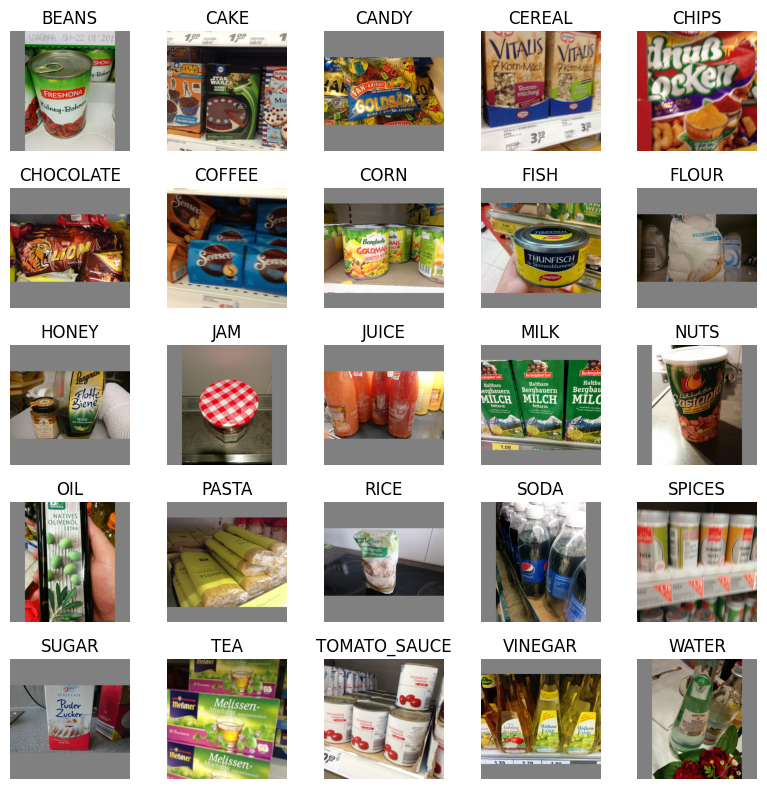

In [5]:
# Get all class folders
# We filtered hidden system files from the dataset directory, because macOS automatically creates files such as .DS_Store, which are not actual class folders.
class_folders = [folder for folder in os.listdir("images") if not folder.startswith(".")]

#We used a 5x5 grid to display one image from each class.
# create 5x5 grid
fig, axes = plt.subplots(5, 5, figsize=(8,8))

for i in range(len(class_folders)):

    # get current class name
    class_name = class_folders[i]

    # path to class folder
    class_folder_path = os.path.join("images", class_name)

    # get first image in folder
    image_name = os.listdir(class_folder_path)[0]

    # full image path
    image_path = os.path.join(class_folder_path, image_name)

    # open image
    image = Image.open(image_path)

    # calculate row and column
    row = i // 5
    col = i % 5

    # show image
    axes[row, col].imshow(image)

    # set title
    axes[row, col].set_title(class_name)

    # remove_axes
    axes[row, col].axis("off")

plt.tight_layout()
plt.show()

# ---------------- DATASET ANALYSIS ----------------
In this section, we analyze the Freiburg Groceries Dataset to better understand.
First, we calculate the total number of images and classes.
Then, we inspect all class names and count how many images
exist in each category.

In [6]:
# print total number of images
print("Total images:", len(dataset))

# print total number of classes
print("Number of classes:", len(class_names))

# print all class names
print("Class names:")
print(class_names)

# count images in each class
print("\nImages per class:")

class_counts = []

for class_name in dataset.classes:

    # create path to class folder
    class_path = os.path.join("images", class_name)

    # count images inside the folder
    image_count = len(os.listdir(class_path))

    # save image count for graph
    class_counts.append(image_count)

    # print class and image count
    print(class_name, ":", image_count)

# open one sample image
sample_class = class_names[0]

sample_folder = os.path.join("images", sample_class)

sample_image_name = os.listdir(sample_folder)[0]

sample_image_path = os.path.join(sample_folder,sample_image_name)

sample_image = Image.open(sample_image_path)

# print image resolution
print("\nImage resolution:", sample_image.size)

Total images: 4947
Number of classes: 25
Class names:
['BEANS', 'CAKE', 'CANDY', 'CEREAL', 'CHIPS', 'CHOCOLATE', 'COFFEE', 'CORN', 'FISH', 'FLOUR', 'HONEY', 'JAM', 'JUICE', 'MILK', 'NUTS', 'OIL', 'PASTA', 'RICE', 'SODA', 'SPICES', 'SUGAR', 'TEA', 'TOMATO_SAUCE', 'VINEGAR', 'WATER']

Images per class:
BEANS : 136
CAKE : 161
CANDY : 372
CEREAL : 278
CHIPS : 181
CHOCOLATE : 307
COFFEE : 298
CORN : 97
FISH : 110
FLOUR : 109
HONEY : 185
JAM : 241
JUICE : 302
MILK : 162
NUTS : 168
OIL : 143
PASTA : 172
RICE : 150
SODA : 177
SPICES : 207
SUGAR : 118
TEA : 283
TOMATO_SAUCE : 171
VINEGAR : 157
WATER : 262

Image resolution: (256, 256)


# ---------------- CLASS DISTRIBUTION GRAPH ----------------
Distribution of Images per Class:
The dataset is not completely balanced because 
some classes contain more images than others. 
For example, categories such as Candy, Chocolate and Juice have more training images, 
while categories such as Corn, Fish and Flour contain fewer samples.

This creates a slight class imbalance in the dataset.
During training, the CNN sees larger classes more often. Because of this, 
the model may learn these categories better and achieve higher accuracy for them.
As a result, the model may achieve lower prediction accuracy for smaller classes.

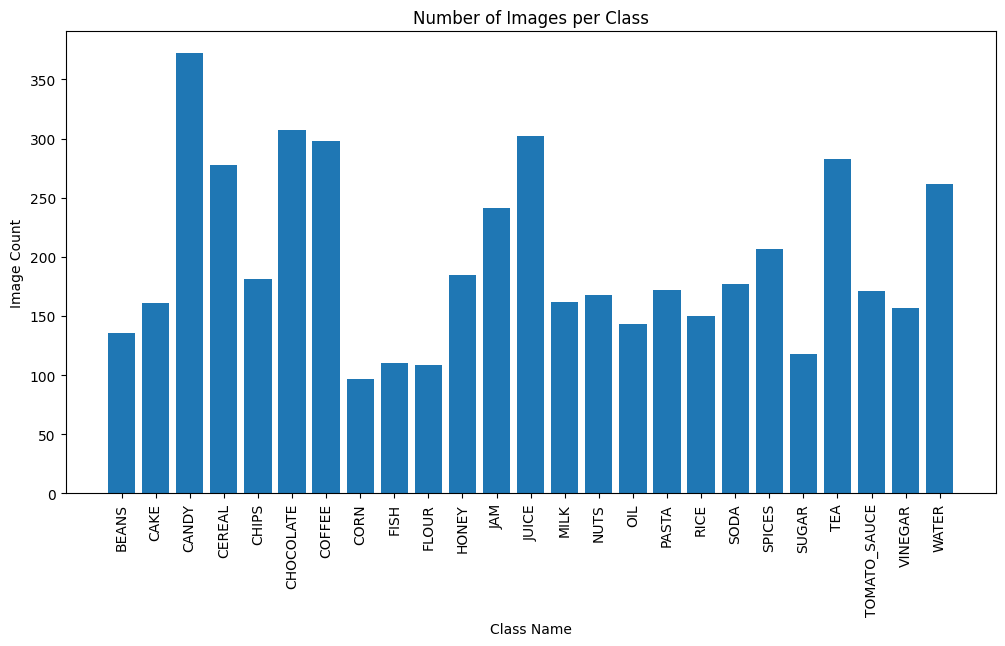

In [7]:
plt.figure(figsize=(12,6))

# create bar chart
plt.bar(dataset.classes, class_counts)

# rotate class names
plt.xticks(rotation=90)

# graph title
plt.title("Number of Images per Class")

# axis labels
plt.xlabel("Class Name")
plt.ylabel("Image Count")

# show graph
plt.show()

# ---------------- PREPROCESSING ----------------
We used three different preprocessing pipelines because training, testing and visualization have different goals.

1. train_transform
This preprocessing is used during CNN training.

Here we apply data augmentation techniques such as:
- random horizontal flip
- random rotation: Images can rotate up to 15 degrees.
- random resized crop: This randomly crops different parts of the image
After augmentation, images are converted into tensors, since PyTorch CNN models cannot directly work with PIL images.
Finally, normalization is applied.

2. test_transform
This preprocessing pipeline is used for the test dataset.
Here we intentionally do NOT use random augmentation techniques such as: 
- RandomHorizontalFlip() 
- RandomRotation() 
- RandomResizedCrop()

The reason is that during testing 
we want to measure the real performance of the CNN as fairly as possible.
During training, random changes are useful because they help the model learn from many slightly different versions of the same image.
However, during testing this would create problems.
For this reason, the test pipeline only conducted non-random transformations such as resizing, tensor conversion and normalization.: 
- resizing: resizing is still necessary because CNN models require a fixed input size.
Inside one batch, all images must have the same dimensions.
By resizing every image to 256x256, the CNN receives a consistent input shape.
- tensor conversion 
- normalization: Normalization is also still necessary during testing
During training, pixel values were scaled into a smaller range.
If normalization were removed during testing, the test images would have a different value distribution than the training images.
This would confuse the CNN because the model weights were optimized using normalized inputs.

In [8]:
train_transform = transforms.Compose([
    # RESIZE standardizes image dimensions before training the CNN model
    transforms.Resize((256, 256)),

    # ROTATION
    # Randomly rotate the image between -15 and +15
    # Every epoch, the same image can be loaded again with a different random rotation. For example, the image might be rotated by +5 in one epoch and by -12 in another epoch.
    transforms.RandomRotation(15),

    # CROP
    # Randomly selects and crops a region of the image
    # between 80% and 100% of the original size,
    # then resizes it to 256x256 pixels.
    # When an image is resized, the number of pixels changes. Because of this, the model needs a method to calculate the values of the new pixels and uses bilinear interpolation for this calculation.
    transforms.RandomResizedCrop(256, scale=(0.8, 1.0),interpolation=InterpolationMode.BILINEAR),

    # TRANSLATION (SHIFT)
    # degrees=0 means that no rotation is applied. The image is not rotated and only translation is performed.
    # translate=(0.1, 0.1) = image can be randomly shifted by up to 10% of its width and height.
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    
    # SHARPEN
    # This transformation sharpens the image before it is converted into a tensor.
    # ImageFilter.SHARPEN is a PIL image filter that increases edge contrast and makes details appear clearer and more defined. For example, object borders and textures may become slightly more visible after sharpening.
    # The transformation is wrapped inside transforms.Lambda(...)
     #because PyTorch does not provide a built-in sharpen transform directly in torchvision.transforms
    transforms.Lambda(lambda img: img.filter(ImageFilter.SHARPEN)),

    # Convert to tensor
    # At the beginning, image is a normal PIL image object created by:Image.open(...)
    # BUT CNN cannot work directly with a PIL image. Neural networks require numerical data that can be processed mathematically.
    # ToTensor() mainly does two things:
    # 1. converts the image into a PyTorch tensor,
    # 2. scales the pixel values from 0–255 to the range 0.0–1.0.
    # and CNN can use for matrix multiplications, forward and backward propagation.
    transforms.ToTensor(),
    
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    
])

# Test preprocessing pipeline
test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],std=[0.5, 0.5, 0.5]),
])

Visualization preprocessing pipeline:
This preprocessing pipeline is only used for visualization. It is NOT used during CNN training or testing.
We could theoretically visualize images directly from the training pipeline, 
but we intentionally used a separate visualization pipeline instead.
The MAIN REASON IS NORMALIZATION. The training pipeline contains normalization.
However, normalized images often look strange when displayed to humans with matplotlib.
For example: colors may look incorrect, images may appear darker, or the contrast may look unusual.
But for presentation and understanding purposes, these images become harder to interpret.

In [9]:
visualization_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(256, scale=(0.8, 1.0), interpolation=InterpolationMode.BILINEAR),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1) ),
    transforms.Lambda(lambda img: img.filter(ImageFilter.SHARPEN)),
    transforms.ToTensor(),
])

# ---------------- SHOWING HOW PREPROCESSING CHANGES IMAGES ----------------

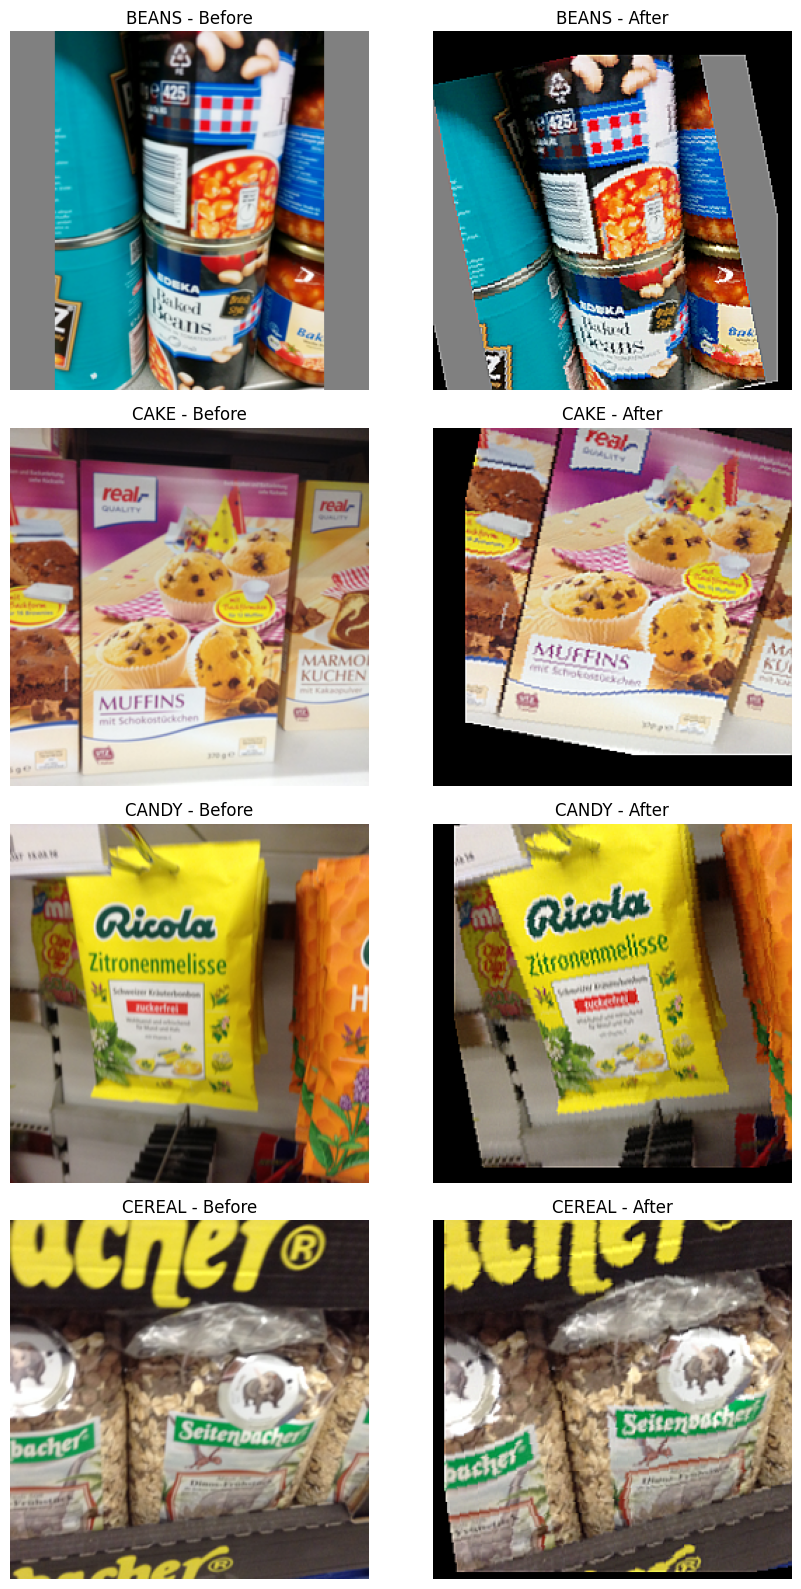

In [10]:
fig, axes = plt.subplots(4, 2, figsize=(10,16))

for i in range(4):

    # Select class
    class_name = class_names[i]

    # Select image
    image_path = os.path.join("images",class_name,random.choice(os.listdir(os.path.join("images", class_name))))

    # Open image
    original_image = Image.open(image_path)

    # Apply preprocessing
    processed_image = visualization_transform(original_image)

    # Convert tensor for matplotlib
    processed_image = processed_image.permute(1, 2, 0)

    # Original image
    axes[i, 0].imshow(original_image)
    axes[i, 0].set_title(f"{class_name} - Before")
    axes[i, 0].axis("off")

    # Processed image
    axes[i, 1].imshow(processed_image)
    axes[i, 1].set_title(f"{class_name} - After")
    axes[i, 1].axis("off")

plt.subplots_adjust(hspace=0.6)
plt.tight_layout()
plt.show()

# ---------------- APPLY PREPROCESSING TO DATASETS ----------------
Here we create two separate ImageFolder datasets, even though both datasets use the same image folder.
The reason is that training dataset uses train_transform.
The test dataset uses test_transform instead.
If we used only one dataset object, both train and test images would receive the exact same transformations.
This would create a problem.
For example: if train_transform were also applied to the test set, then test images would randomly change every run.
This would make evaluation unreliable.

However, at this point, both datasets still contain ALL images.
The split has not happened yet.
The actual splitting happens later with train_test_split().

In [11]:
train_dataset = datasets.ImageFolder(root="images", transform=train_transform)
test_dataset = datasets.ImageFolder(root="images", transform=test_transform)
num_classes = len(train_dataset.classes)

# ---------------- TRAIN / TEST SPLIT ----------------
First, all dataset indices are created:
For example: if the dataset contains 5000 images, the indices become:
[0, 1, 2, 3, ..., 4999]

In [12]:
indices = list(range(len(train_dataset)))

Then train_test_split() divides these indices into: 
- training indices 
- testing indices

In [13]:
train_idx, test_idx = train_test_split(indices,test_size=TEST_RATIO,stratify=train_dataset.targets,random_state=SEED,)

After that, Subset is used.
By using subset, for example we are using only the training indices from train_dataset.
So both datasets share the same original image folder, but: 
- they use different transforms!!!
- they use different subsets of indices!!!
!!!! This is why we first create two dataset objects, and only afterwards split them with Subset.

In [14]:
train_set = Subset(train_dataset, train_idx)
test_set = Subset(test_dataset, test_idx)

# ---------------- HANDLING CLASS IMBALANCE ----------------
Our dataset contains slight class imbalance,
because some categories contain more images than others. 
compute_class_weight() helps reduce this imbalance 
by assigning larger weights to smaller classes 
and smaller weights to larger classes.

In [15]:
# Calculate class weights to help reduce class imbalance
class_weights = compute_class_weight(class_weight="balanced",classes=np.arange(num_classes),y=train_dataset.targets)

# Convert weights into PyTorch tensor 
# because CrossEntropyLoss expects tensor input
class_weights = torch.tensor(class_weights,dtype=torch.float).to(device)

print("Class weights:")
print(class_weights)

Class weights:
tensor([1.4550, 1.2291, 0.5319, 0.7118, 1.0933, 0.6446, 0.6640, 2.0400, 1.7989,
        1.8154, 1.0696, 0.8211, 0.6552, 1.2215, 1.1779, 1.3838, 1.1505, 1.3192,
        1.1180, 0.9559, 1.6769, 0.6992, 1.1572, 1.2604, 0.7553],
       device='cuda:0')


DataLoader is responsible for loading the dataset in smaller batches during CNN training and testing.
The train_loader is used during training. Here shuffle=True is enabled.
This means the image order is randomized at the beginning of every epoch.
For example, during epoch 1,  CNN may first see water, coffee, cereal, vinegar. During epoch 2, the order may become: juice, pasta, milk, tea.
This is important because if the CNN always sees images in the exact same order, the model may start learning order-related patterns.

For the test_loader, shuffle=False is used. 
Because during testing, model is not learning anymore. It is only making predictions.
Because of this, there is no advantage in randomizing the image order.

In [16]:
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

# ---------------- CNN MODEL ----------------
In this project, we used PyTorch instead of TensorFlow to build and train our CNN model.
PyTorch provides things such as: 
- nn.Conv2d 
- nn.MaxPool2d 
- nn.Linear 
- nn.ReLU

In our implementation, we created our CNN architecture inside a class called SimpleCNN.
This class inherits from nn.Module, which is the base class used for neural networks in PyTorch.

Inside this class, we define all CNN layers such as convolution layers, pooling layers and fully connected layers.

In [17]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # First convolution layer
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        # Second convolution layer
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        # Third convolution layer
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        # Max pooling layer
        self.pool = nn.MaxPool2d(2)
        # ReLU activation introduces non-linearity
        self.relu = nn.ReLU()
        # Flatten converts multi-dimensional feature maps into a one-dimensional vector
        # because fully connected layers expect vector input
        self.flatten = nn.Flatten()
        # First fully connected layer
        self.fc1 = nn.Linear(64 * 32 * 32, 128)
        self.dropout = nn.Dropout(0.5)
        # Final output layer
        self.fc2 = nn.Linear(128, num_classes)

    # forward() defines how image data moves through the CNN model.
    # forward() is automatically called when we use: model(images)
    # For example: logits = model(images)
    # Internally, PyTorch automatically runs: model.forward(images)
    # Because of this, we  do not call forward() manually.
    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.pool(self.relu(self.conv3(x)))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# ---------------- LOSS FUNCTION AND OPTIMIZER ----------------

In [18]:
# Create CNN model and move it to the selected device
model = SimpleCNN(num_classes).to(device)

CrossEntropyLoss is the loss function used for multi-class image classification problems. 
Loss function measures how different the CNN predictions are from the correct labels.
We also pass class_weights into CrossEntropyLoss.
By passing class_weights into CrossEntropyLoss,smaller classes become more important during training.

In [19]:
criterion = nn.CrossEntropyLoss(weight=class_weights)

Adam is the optimizer responsible for updating the CNN weights during training.
After backpropagation calculates gradients, Adam uses these gradients to adjust the weights in order to reduce the loss.
loss.backward()

In [20]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

ReduceLROnPlateau automatically reduces the learning rate when the test/validation loss stops improving. 
mode="min" -> scheduler expects the monitored value to decrease. 
factor=0.5 -> learning rate becomes half its previous value. 
patience=3 -> scheduler waits 3 epochs without improvement before reducing the learning rate.

In [21]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

# ---------------- ACCURACY HISTORY ----------------

In [22]:
train_acc_history = []
test_acc_history = []

# ---------------- EARLY STOPPING ----------------
Early stopping helps prevent overfitting. 
If the test loss stops improving for several epochs, 
training is stopped automatically.

In [23]:
best_loss = float("inf")

patience_counter = 0
#If the validation/test loss does not improve for 5 consecutive epochs, the training process is stopped.
PATIENCE = 5

# ---------------- TRAINING LOOP ----------------

In [24]:
all_predictions = []
all_labels = []

# Training loop
for epoch in range(1, NUM_EPOCHS + 1):
    # train
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (logits.argmax(1) == labels).sum().item()
        train_total += images.size(0)

    # --- eval ---
    # During evaluation: 
    # - dropout is disabled 
    # - weights are not updated 
    # - model only performs predictions
    model.eval()
    
    test_loss, test_correct, test_total = 0.0, 0, 0

    # torch.no_grad(): 
    # - disables gradient calculation during evaluation/testing.
    # - makes evaluation faster
    # This is important because backpropagation is only needed during training.
    with torch.no_grad():
        # Iterate through the test dataset batch by batch
        for images, labels in test_loader:
            images= images.to(device)
            labels = labels.to(device)
            # The output is called logits.
            logits = model(images)
            predictions = logits.argmax(1)
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            loss = criterion(logits, labels)
            
            test_loss += loss.item() * images.size(0)
            test_correct += (logits.argmax(1) == labels).sum().item()
            test_total += images.size(0)

    avg_test_loss = test_loss / test_total

    # ---------------- EARLY STOPPING CHECK ----------------
    # Check whether the current test loss improved
    if avg_test_loss < best_loss:
        # Save new best loss
        best_loss = avg_test_loss
        # Reset patience counter
        patience_counter = 0

    else:
        # Increase patience counter 
        # because test loss did not improve
        patience_counter += 1

    # Save metrics for visualization
    # These values are later used in the accuracy graph
    train_acc_history.append(train_correct / train_total)
    test_acc_history.append(test_correct / test_total)

    # Stop training if the model 
    # does not improve for multiple epochs
    if patience_counter >= PATIENCE:
        print("Early stopping triggered.")
        break
    
    # Reduce learning rate automatically 
    # when the validation/test loss stops improving
    scheduler.step(avg_test_loss)
    # Get current learning rate
    current_lr = optimizer.param_groups[0]["lr"]
   
    # Print training and testing metrics
    print(f"epoch {epoch}/{NUM_EPOCHS} | "
          f"train loss {train_loss / train_total:.4f} "
          f"train acc {train_correct / train_total:.3f} | "
          f"test loss {avg_test_loss:.4f} "
          f"test acc {test_correct / test_total:.3f} | "
          f"lr {current_lr:.1e}")

epoch 1/50 | train loss 3.2287 train acc 0.042 | test loss 3.1669 test acc 0.051 | lr 1.0e-03
epoch 2/50 | train loss 3.1580 train acc 0.067 | test loss 3.1648 test acc 0.070 | lr 1.0e-03
epoch 3/50 | train loss 3.0773 train acc 0.085 | test loss 3.0105 test acc 0.110 | lr 1.0e-03
epoch 4/50 | train loss 2.9914 train acc 0.115 | test loss 2.9709 test acc 0.141 | lr 1.0e-03
epoch 5/50 | train loss 2.9303 train acc 0.127 | test loss 2.8492 test acc 0.145 | lr 1.0e-03
epoch 6/50 | train loss 2.8527 train acc 0.155 | test loss 2.7204 test acc 0.182 | lr 1.0e-03
epoch 7/50 | train loss 2.7724 train acc 0.174 | test loss 2.7303 test acc 0.209 | lr 1.0e-03
epoch 8/50 | train loss 2.7103 train acc 0.198 | test loss 2.5407 test acc 0.238 | lr 1.0e-03
epoch 9/50 | train loss 2.6710 train acc 0.206 | test loss 2.5714 test acc 0.237 | lr 1.0e-03
epoch 10/50 | train loss 2.6170 train acc 0.222 | test loss 2.4492 test acc 0.254 | lr 1.0e-03
epoch 11/50 | train loss 2.5156 train acc 0.239 | test loss

# ---------------- ACCURACY GRAPH ----------------
accuracy graph shows how the model performance changes during training over multiple epochs.
if both training and test accuracy improve over time, we can say, model is learning successfully.
if the training accuracy continues to increase while the test accuracy stops improving or decreases, this may indicate overfitting.

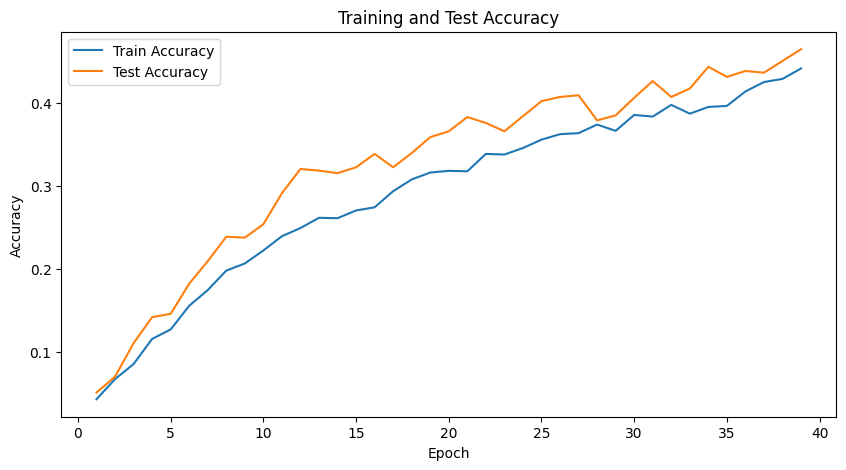

In [25]:
plt.figure(figsize=(10,5))

epochs = range(1, len(train_acc_history) + 1)

plt.plot(epochs, train_acc_history, label="Train Accuracy")
plt.plot(epochs, test_acc_history, label="Test Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training and Test Accuracy")

plt.legend()

plt.show()

# ---------------- CONFUSION MATRIX ----------------

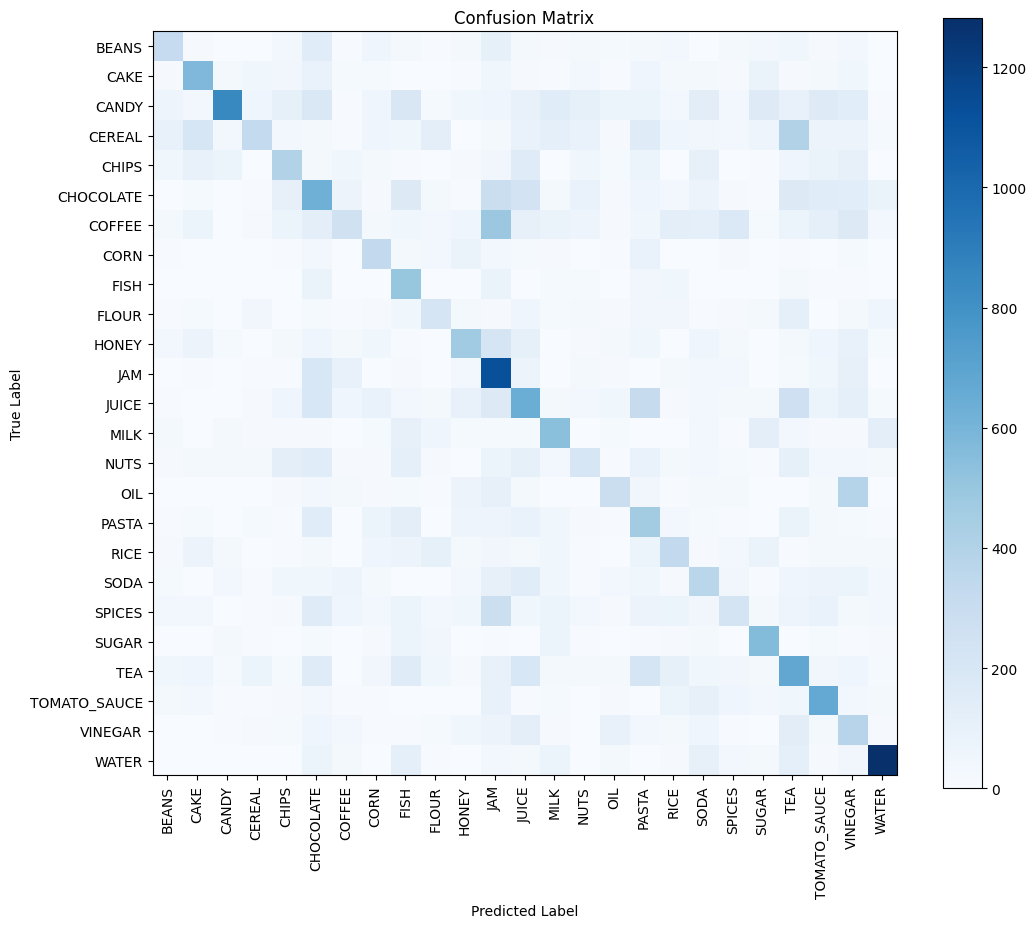

In [26]:
# CM helps identify which classes are predicted correctly and which classes are not
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(12,10))

plt.imshow(cm, cmap="Blues")

plt.xticks(range(len(class_names)), class_names, rotation=90)
plt.yticks(range(len(class_names)), class_names)

plt.title("Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Add color scale bar
plt.colorbar()
# Show graph
plt.show()